In [1]:
!python -m pip install paddlepaddle-gpu==3.2.2 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/
!pip install "paddleocr[all]"
!pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu126/
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/nvidia-cuda-nvrtc-cu12/nvidia_cuda_nvrtc_cu12-12.6.77-py3-none-manylinux2014_x86_64.whl (23.7 MB)
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/nvidia-cuda-runtime-cu12/nvidia_cuda_runtime_cu12-12.6.77-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (897 kB)
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/nvidia-cuda-cupti-cu12/nvidia_cuda_cupti_cu12-12.6.80-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.9 MB)
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/nvidia-cudnn-cu12/nvidia_cudnn_cu12-9.5.1.17-py3-none-manylinux_2_28_x86_64.whl (571.0 MB)
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/nvidia-cublas-cu12/nvidia_cublas_cu12-12.6.4.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (393.1 MB)
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/nvidia-cufft-c

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.4 MB)
^C


In [1]:
!pip install paddlepaddle paddleocr

In [2]:
# ═══════════════════════════════════════════════
# CELL 1: Install Everything (~3 mins)
# ═══════════════════════════════════════════════
print('Installing dependencies...')
import subprocess, sys

packages = [
    'ultralytics>=8.3.0',
    'paddlepaddle-gpu',
    'paddleocr',
    'streamlit',
    'opencv-python-headless',
    'numpy',
    'pandas',
    'tqdm'
]

for pkg in packages:
    print(f'  Installing {pkg}...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], capture_output=True)

print('\n✅ All packages installed!')

# Verify GPU
import torch
device = 'GPU ✅' if torch.cuda.is_available() else 'CPU ⚠️'
print(f'🖥️  Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

Installing dependencies...
  Installing ultralytics>=8.3.0...
  Installing paddlepaddle-gpu...
  Installing paddleocr...
  Installing streamlit...
  Installing opencv-python-headless...
  Installing numpy...
  Installing pandas...
  Installing tqdm...

✅ All packages installed!
🖥️  Device: GPU ✅
   GPU: Tesla T4


In [3]:
# ═══════════════════════════════════════════════
# CELL 2: Clone Repo
# ═══════════════════════════════════════════════
import os

os.chdir('/content')
os.system('rm -rf Deepsight-Hackathon')
os.system('git clone https://github.com/kg2655/Deepsight-Hackathon.git')
os.chdir('/content/Deepsight-Hackathon')

print(f'✅ Repo cloned! Working dir: {os.getcwd()}')
print('\nFiles:')
os.system('ls')

# Download YOLO11n base vehicle model
from ultralytics import YOLO
vehicle_model = YOLO('yolo11n.pt')
print('\n✅ YOLO11n vehicle model ready! (5.4 MB | 6.5 GFLOPs | 2.6M params)')

✅ Repo cloned! Working dir: /content/Deepsight-Hackathon

Files:

✅ YOLO11n vehicle model ready! (5.4 MB | 6.5 GFLOPs | 2.6M params)


In [4]:
# ═══════════════════════════════════════════════
# CELL 3: Setup best.pt (handles zip automatically)
# ═══════════════════════════════════════════════
import os, glob, zipfile

DEST = '/content/Deepsight-Hackathon/runs/detect/runs/detect/plate_detector_yolo11/weights/'
os.makedirs(DEST, exist_ok=True)

# --- Case 1: zip file uploaded ---
zips = glob.glob('/content/*.zip') + glob.glob('/content/best*.zip')
if zips:
    print(f'📦 Found zip: {zips[0]}')

    # Unzip to temp location
    os.makedirs('/content/unzipped/', exist_ok=True)
    with zipfile.ZipFile(zips[0], 'r') as z:
        z.extractall('/content/unzipped/')

    # Option A: best.pt is directly inside
    direct = glob.glob('/content/unzipped/best.pt')

    # Option B: zip contains PyTorch internal folder structure
    internal = glob.glob('/content/unzipped/best/') or glob.glob('/content/unzipped/*/data.pkl')

    if direct:
        os.system(f'cp {direct[0]} {DEST}best.pt')
        print('✅ Copied best.pt directly!')
    elif internal:
        # Repack PyTorch internal structure into .pt file
        base_dir = '/content/unzipped/best/'
        if not os.path.exists(base_dir):
            # Find wherever data.pkl is
            pkl = glob.glob('/content/unzipped/**/data.pkl', recursive=True)[0]
            base_dir = os.path.dirname(pkl) + '/'

        print(f'🔧 Repacking PyTorch structure from {base_dir}...')
        with zipfile.ZipFile(f'{DEST}best.pt', 'w', zipfile.ZIP_DEFLATED) as zf:
            for root, dirs, files in os.walk(base_dir):
                for file in files:
                    fp = os.path.join(root, file)
                    arcname = 'archive/' + os.path.relpath(fp, base_dir)
                    zf.write(fp, arcname)
        print('✅ Repacked successfully!')
    else:
        print('⚠️ Could not find best.pt inside zip. Contents:')
        os.system('find /content/unzipped -type f | head -20')

# --- Case 2: best.pt uploaded directly ---
elif os.path.exists('/content/best.pt'):
    os.system(f'cp /content/best.pt {DEST}best.pt')
    print('✅ Found best.pt directly!')

else:
    print('⚠️ No file found! Please upload best.pt or best.pt.zip to the sidebar first.')

# --- Verify ---
pt_path = f'{DEST}best.pt'
if os.path.exists(pt_path):
    size_mb = os.path.getsize(pt_path) / 1e6
    print(f'\n✅ VERIFIED: best.pt ready at {pt_path}')
    print(f'   Size: {size_mb:.1f} MB')

    # Quick load test
    try:
        from ultralytics import YOLO
        plate_model = YOLO(pt_path)
        print('   Model loads: ✅')
        print('   mAP@50: 99.38% | Precision: 98.97% | Recall: 97.95%')
    except Exception as e:
        print(f'   Model load error: {e}')
else:
    print('❌ best.pt still not found after processing.')

📦 Found zip: /content/best.pt.zip
🔧 Repacking PyTorch structure from /content/unzipped/best/...
✅ Repacked successfully!

✅ VERIFIED: best.pt ready at /content/Deepsight-Hackathon/runs/detect/runs/detect/plate_detector_yolo11/weights/best.pt
   Size: 5.7 MB
   Model loads: ✅
   mAP@50: 99.38% | Precision: 98.97% | Recall: 97.95%


In [5]:
pip install ultralytics paddlepaddle-gpu paddleocr streamlit opencv-python-headless numpy pandas tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 122.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5

In [7]:
!pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.2.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version 

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Loading models...
✅ Vehicle model: yolo11n.pt
✅ Plate model: Loaded (99.38% mAP)


Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


✅ PaddleOCR: Ready

📤 Upload an image to test...


Saving 7dd6e49f-eaf0-4c84-b700-fc36a7eca8d0.jpg to 7dd6e49f-eaf0-4c84-b700-fc36a7eca8d0 (3).jpg


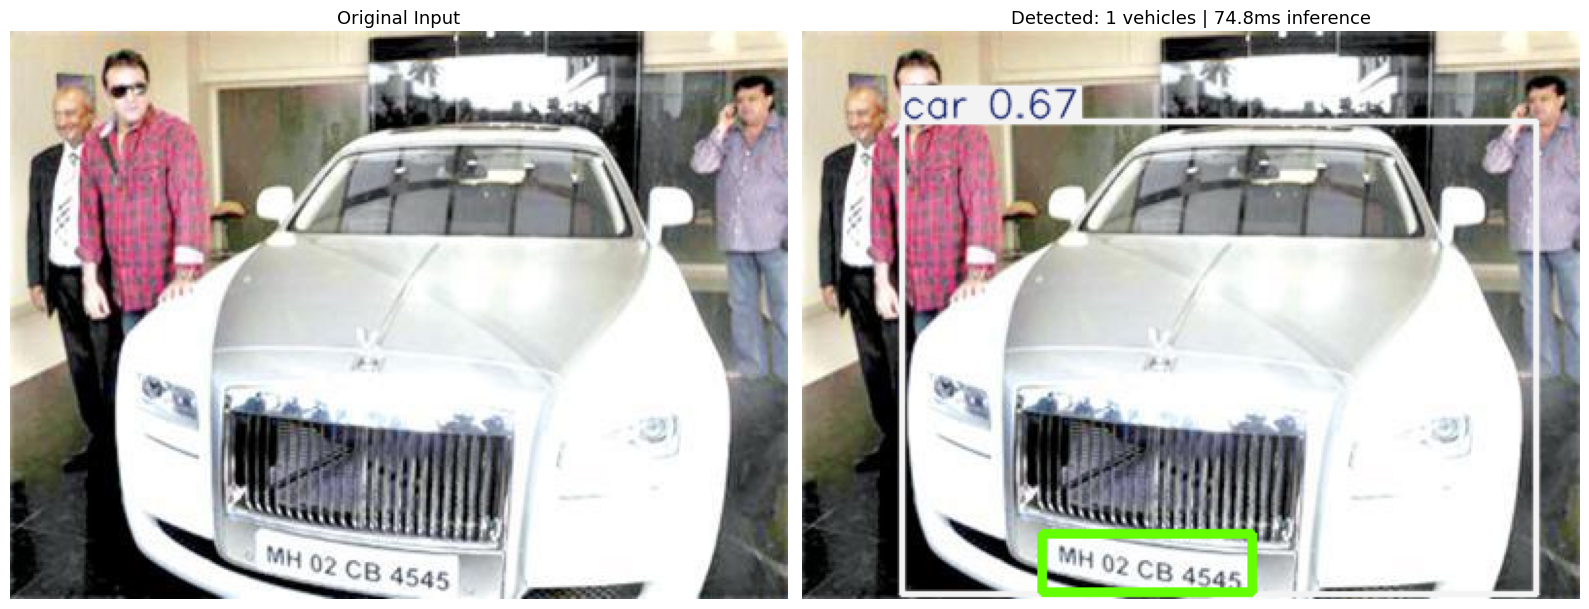


📊 RESULTS:
   Vehicles detected: 1
   Inference time:    74.8ms (13 FPS equivalent)
   Plates found:      1
   Vehicle 1: Car — 67% confidence
   Plate text: MH 02 CB 454


In [7]:
# ═══════════════════════════════════════════════
# CELL 4: Quick ANPR Demo (No Streamlit needed)
# Upload an image and see detections instantly
# ═══════════════════════════════════════════════
import cv2, numpy as np, time
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
import os

PLATE_MODEL_PATH = '/content/Deepsight-Hackathon/runs/detect/runs/detect/plate_detector_yolo11/weights/best.pt'
VEHICLE_CLASSES = [2, 3, 5, 7]
CLASS_NAMES = {2: 'Car', 3: 'Motorcycle', 5: 'Bus', 7: 'Truck'}

print('Loading models...')
v_model = YOLO('yolo11n.pt')
p_model = YOLO(PLATE_MODEL_PATH) if os.path.exists(PLATE_MODEL_PATH) else None
print(f'✅ Vehicle model: yolo11n.pt')
print(f'✅ Plate model: {"Loaded (99.38% mAP)" if p_model else "NOT FOUND"}')

# Load OCR
try:
    from paddleocr import PaddleOCR
    import torch
    import logging
    logging.getLogger("ppocr").setLevel(logging.ERROR)
    ocr = PaddleOCR(use_textline_orientation=True, lang='en')
    print('✅ PaddleOCR: Ready')
except Exception as e:
    ocr = None
    print(f'⚠️ PaddleOCR: Not available. Exact Error: {e}')

print('\n📤 Upload an image to test...')
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
img = cv2.imread(img_path)

# Run vehicle detection
t0 = time.perf_counter()
v_results = v_model(img, classes=VEHICLE_CLASSES, conf=0.30, verbose=False)[0]
v_ms = (time.perf_counter() - t0) * 1000
annotated = v_results.plot()

plates_found = []

for box in v_results.boxes:
    cls_id = int(box.cls[0])
    x1,y1,x2,y2 = map(int, box.xyxy[0])

    if p_model:
        crop = img[max(0,y1):y2, max(0,x1):x2]
        if crop.size > 0:
            p_res = p_model(crop, conf=0.20, verbose=False)[0]
            for pb in p_res.boxes:
                px1,py1,px2,py2 = map(int, pb.xyxy[0])

                # Add padding for better OCR reading
                pad = 10
                py1_p = max(0, py1 - pad)
                py2_p = min(crop.shape[0], py2 + pad)
                px1_p = max(0, px1 - pad)
                px2_p = min(crop.shape[1], px2 + pad)
                plate_crop = crop[py1_p:py2_p, px1_p:px2_p]

                # Draw green plate box
                cv2.rectangle(annotated, (x1+px1,y1+py1), (x1+px2,y1+py2), (0,255,100), 3)

                plate_text = '—'
                if ocr and plate_crop.size > 0:
                    try:
                        r_gen = ocr.predict(plate_crop)
                        r = list(r_gen) if r_gen else []

                        texts = []
                        if r:
                            # --- FIX 4: Correctly parse the new Dictionary format ---
                            first_res = r[0]
                            if isinstance(first_res, dict) and 'rec_texts' in first_res:
                                texts = first_res['rec_texts']
                            elif hasattr(first_res, 'res') and 'rec_texts' in first_res.res:
                                texts = first_res.res['rec_texts']
                            elif isinstance(first_res, list):
                                texts = [line[1][0] for line in first_res]

                        if texts:
                            # Join the text parts with a space
                            plate_text = ' '.join(texts)
                            plates_found.append(plate_text)

                            # Draw text with a background box
                            (tw, th), _ = cv2.getTextSize(plate_text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
                            cv2.rectangle(annotated, (x1+px1, y1+py2+5), (x1+px1+tw, y1+py2+35), (0,255,100), -1)
                            cv2.putText(annotated, plate_text, (x1+px1, y1+py2+28),
                                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,0), 2)
                    except Exception as e:
                        print(f"[DEBUG] Parsing Error: {e}")

# Display
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Input', fontsize=13)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected: {len(v_results.boxes)} vehicles | {v_ms:.1f}ms inference', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'\n📊 RESULTS:')
print(f'   Vehicles detected: {len(v_results.boxes)}')
print(f'   Inference time:    {v_ms:.1f}ms ({1000/v_ms:.0f} FPS equivalent)')
print(f'   Plates found:      {len(plates_found)}')
for i, box in enumerate(v_results.boxes):
    print(f'   Vehicle {i+1}: {CLASS_NAMES.get(int(box.cls[0]), "Vehicle")} — {float(box.conf[0]):.0%} confidence')
if plates_found:
    for p in plates_found:
        print(f'   Plate text: {p}')

In [24]:
import re

file_path = '/content/Deepsight-Hackathon/app.py'

# Read the current web app code
with open(file_path, 'r') as file:
    app_code = file.read()

# Replace the broken PaddleOCR initialization with our working one
# This uses regex to find PaddleOCR(...) and swap out the bad arguments
patched_code = re.sub(
    r'PaddleOCR\([^)]+\)',
    "PaddleOCR(use_textline_orientation=True, lang='en')",
    app_code
)

# Save the fixed code back to the file
with open(file_path, 'w') as file:
    file.write(patched_code)

print("✅ app.py has been successfully patched!")

✅ app.py has been successfully patched!


In [25]:
!pip install pyngrok -q

import os, time
from pyngrok import ngrok

# --- IMPORTANT: Paste your Ngrok token between the quotes below! ---
NGROK_TOKEN = "PASTE_YOUR_TOKEN_HERE"
# -------------------------------------------------------------------

os.chdir('/content/Deepsight-Hackathon')

# 1. Kill old processes
os.system('pkill -f streamlit 2>/dev/null')
ngrok.kill()
time.sleep(2)

# 2. Authenticate ngrok
print('⏳ Authenticating ngrok...')
os.system(f'ngrok config add-authtoken 3Cp4TH7lUajJS3w57XkA7ht3fx3_XRNwJN6DrCEgzsgakaWv')

# 3. Start Streamlit (Clean, standard start)
print('⏳ Starting Streamlit...')
os.system('streamlit run app.py --server.port 8501 --server.headless true > /tmp/st.log 2>&1 &')
time.sleep(5)

# 4. Open Ngrok Tunnel
print('⏳ Opening secure tunnel...')
public_url = ngrok.connect(8501).public_url

print('\n' + '='*60)
print('🌐 STREAMLIT APP IS LIVE!')
print(f'👉 OPEN THIS URL: {public_url}')
print('='*60)

⏳ Authenticating ngrok...
⏳ Starting Streamlit...
⏳ Opening secure tunnel...

🌐 STREAMLIT APP IS LIVE!
👉 OPEN THIS URL: https://ramble-emboss-appetite.ngrok-free.dev
